# Major Studios Works Analysis
Analyze the number of works produced by major anime studios over the years. Identify trends in production volume and highlight any significant changes or patterns.

In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lib.dbconnection as dbc

# Setup grafico
sns.set_theme(style="whitegrid")

In [2]:
# --- 1. IDENTIFICARE GLI ANIME "DI SUCCESSO" (DuckDB su Parquet) ---
PARQUET_PATH = '../../../cleaned_data/ratings_cleaned.parquet'

# Senza questo, gli '0' (utenti che non hanno votato) abbassano la media drasticamente.
query_success = f"""
    SELECT
        anime_id,
        AVG(score) as avg_score,
        COUNT(score) as vote_count
    FROM read_parquet('{PARQUET_PATH}')
    WHERE score > 0
    GROUP BY anime_id
    HAVING AVG(score) >= 7.5 AND COUNT(score) > 50
"""

print("1. Estrazione anime di successo (DuckDB)...")
df_successful_anime = duckdb.sql(query_success).df()
print(f"Trovati {len(df_successful_anime)} anime con media alta.")





1. Estrazione anime di successo (DuckDB)...
Trovati 1473 anime con media alta.


In [3]:
# --- 2. CARICAMENTO E PULIZIA (Postgres + Pandas) ---
# Se il passaggio 1 trova anime, questo codice ora funzionerà
if not df_successful_anime.empty:
    engine = dbc.create_db_engine()

    # Carichiamo persone e lavori
    query_works = "SELECT person_mal_id, anime_mal_id, position FROM person_anime_works"
    query_people = "SELECT person_mal_id, name FROM person_details"

    df_works = pd.read_sql(query_works, engine)
    df_people = pd.read_sql(query_people, engine)

    # Conversione ID anime da Text a Numeric per il match
    df_works['anime_mal_id'] = pd.to_numeric(df_works['anime_mal_id'], errors='coerce')
    df_works = df_works.dropna(subset=['anime_mal_id'])

    # Filtro: Teniamo solo i lavori sugli anime di successo
    successful_ids = df_successful_anime['anime_id'].unique()
    df_works_success = df_works[df_works['anime_mal_id'].isin(successful_ids)]

    # Conteggio opere
    prolific_creators = df_works_success.groupby('person_mal_id')['anime_mal_id'].nunique().reset_index()
    prolific_creators.columns = ['person_mal_id', 'successful_works_count']

    # Join con i nomi
    top_creators = pd.merge(prolific_creators, df_people, on='person_mal_id', how='left')
    top_15_creators = top_creators.sort_values(by='successful_works_count', ascending=False).head(15)

else:
    print("Nessun anime trovato. Controlla il percorso del file Parquet o abbassa la soglia del voto.")


In [4]:
# --- 3. PULIZIA E INCROCIO DATI (Pandas) ---
print("3. Elaborazione e Type Casting...")

# CRITICO: Dalle immagini, 'anime_mal_id' su Postgres è TEXT, mentre su Parquet è INTEGER.
# Dobbiamo convertirlo in numerico per fare il match.
# errors='coerce' trasformerà eventuali stringhe non numeriche in NaN
df_works['anime_mal_id'] = pd.to_numeric(df_works['anime_mal_id'], errors='coerce')

# Rimuoviamo righe dove l'ID non è stato convertito (se ce ne sono)
df_works = df_works.dropna(subset=['anime_mal_id'])

# Filtriamo solo i lavori fatti sugli anime "di successo"
# Usiamo la lista di ID ottenuta da DuckDB
successful_ids = df_successful_anime['anime_id'].unique()
df_works_success = df_works[df_works['anime_mal_id'].isin(successful_ids)]

# Contiamo le opere uniche per ogni persona
prolific_creators = df_works_success.groupby('person_mal_id')['anime_mal_id'].nunique().reset_index()
prolific_creators.columns = ['person_mal_id', 'successful_works_count']

# Aggiungiamo i nomi delle persone (Join con person_details)
top_creators = pd.merge(prolific_creators, df_people, on='person_mal_id', how='left')

# Prendiamo la Top 15
top_15_creators = top_creators.sort_values(by='successful_works_count', ascending=False).head(15)

print("Analisi completata. Ecco i primi risultati:")
print(top_15_creators[['name', 'successful_works_count']])

3. Elaborazione e Type Casting...
Analisi completata. Ecco i primi risultati:
                   name  successful_works_count
102         Justin Cook                     196
696        Gen Fukunaga                     131
1619   Tomoyuki Ooshita                     115
7607   Takenori Tsukuma                     115
1295      Jin Aketagawa                     113
1297      Jin Aketagawa                     113
1296      Jin Aketagawa                     113
2305   Atsuhiro Iwakami                     109
9280     Kazunori Ozawa                      98
2164    Toshiyuki Satou                      88
8793     Samantha Herek                      87
3264          Misao Abe                      85
7916     Kozue Kananiwa                      85
10535  Junko Matsushita                      79
1133     Youta Tsuruoka                      78


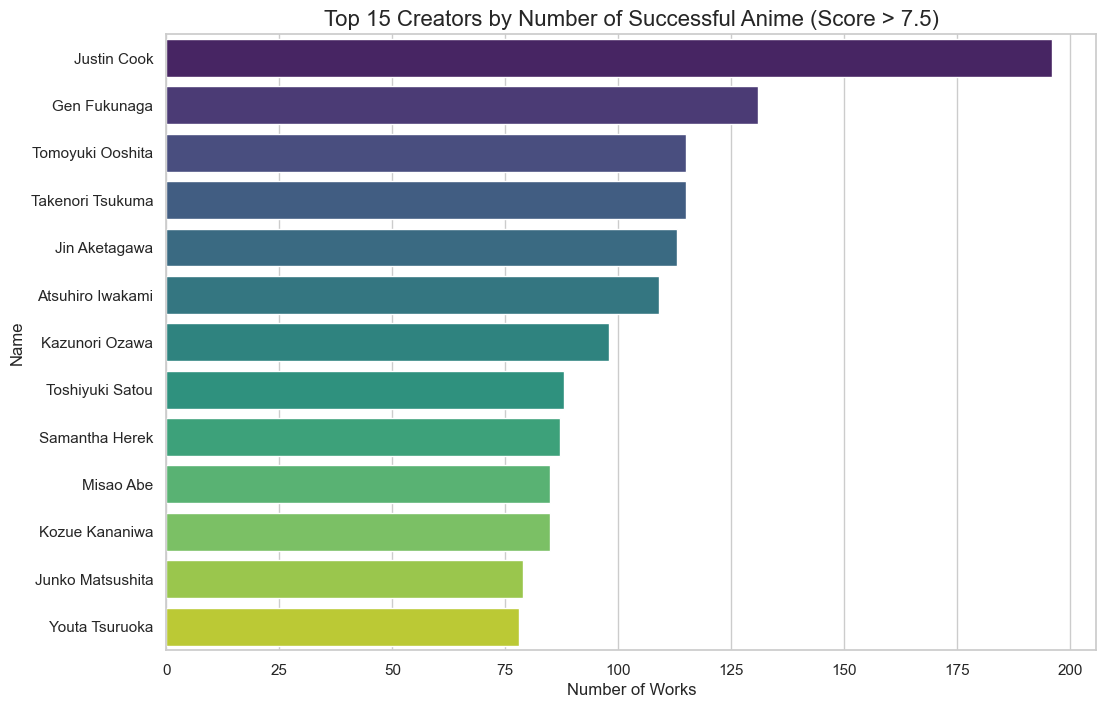

In [5]:
# Plot
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_15_creators,
    x='successful_works_count',
    y='name',
    hue='name',
    palette='viridis'
)
plt.title('Top 15 Creators by Number of Successful Anime (Score > 7.5)', fontsize=16)
plt.xlabel('Number of Works')
plt.ylabel('Name')

plt.savefig('../../images/creatorsBySuccessfulAnime.png', dpi=300, bbox_inches='tight')

plt.show()